[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YangKCLab/social-media-analysis/blob/main/docs/topics/visualization/seaborn-and-plotly.ipynb)

# Seaborn and Plotly

Matplotlib is the basic plotting library of Python, and other tools build on it or work next to it.
This notebook has two examples with seaborn, which makes common statistical figures with one call, and one example with Plotly, which makes interactive figures for a web page.

Sections: Joint plot, Annotated heatmap, Interactive scatter plot with Plotly, Save the interactive figure.

Packages beyond the standard library: `matplotlib`, `numpy`, `pandas`, `plotly`, `seaborn`.
Install them with `uv add matplotlib numpy pandas plotly seaborn` (or `pip install`).
Colab already has all five.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

## Joint plot

A joint plot shows two numbers together in the middle, and the histogram of each number on the sides.
The example is from the [seaborn gallery](https://seaborn.pydata.org/examples/hexbin_marginals.html).
The data is 1,000 pairs of random numbers.

`sns.set_theme(style="ticks")` changes the look of every later figure of the notebook: the fonts, the colors, and the axes.
`kind="hex"` draws the middle as a grid of hexagons, and a darker hexagon holds more points.

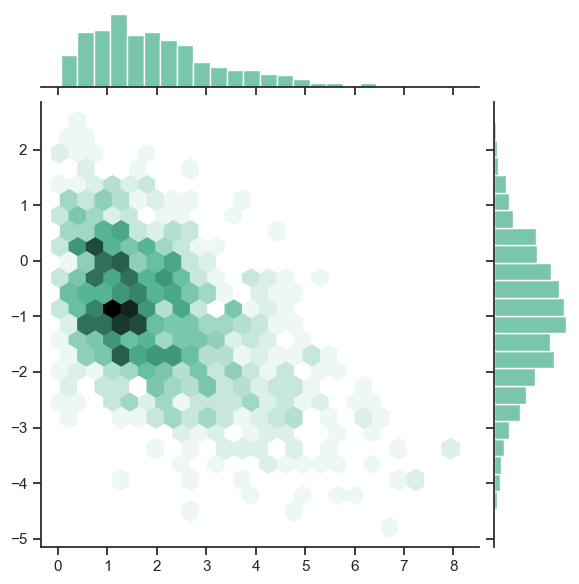

In [2]:
sns.set_theme(style="ticks")

rs = np.random.RandomState(11)
x = rs.gamma(2, size=1000)
y = -.5 * x + rs.normal(size=1000)

sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")
plt.show()

The darkest hexagons are near `x` = 1 and `y` = -1, so most points are there.
The histogram on top shows that `x` is skewed to the right.
The middle shows that `y` falls when `x` rises.

One call draws the three parts and lines them up.
With Matplotlib alone, the same figure takes many more lines.

## Annotated heatmap

The data is the number of international airline passengers in each month from 1949 to 1960,
in thousands. It is the airline data of Box, Jenkins, and Reinsel (1976), *Time Series
Analysis, Forecasting and Control*. The cell downloads the file `flights.csv` from the
repository of the seaborn example data,
[mwaskom/seaborn-data](https://github.com/mwaskom/seaborn-data), at a fixed commit.

In [3]:
FLIGHTS_URL = (
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/"
    "71e2436a092d714350de0fc409ca8a8714e7e78f/flights.csv"
)
flights_long = pd.read_csv(FLIGHTS_URL)
# Keep the months in calendar order, as sns.load_dataset does.
months = flights_long["month"].str[:3]
flights_long["month"] = pd.Categorical(months, months.unique())
flights_long.head(3)

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132


The table has 144 rows, one for each month of the 12 years.

| | year | month | passengers |
| --- | --- | --- | --- |
| 0 | 1949 | Jan | 112 |
| 1 | 1949 | Feb | 118 |
| 2 | 1949 | Mar | 132 |

The file has the full names of the months.
The last two lines of the cell shorten each name to three letters and store the calendar order of the months.
Without them, the next cell sorts the months by the alphabet: April, August, December, and so on.

A heatmap needs a table with one row for each month and one column for each year.
`pivot` builds it.

In [4]:
flights = flights_long.pivot(index="month", columns="year", values="passengers")
flights.shape

(12, 12)

The result is `(12, 12)`: 12 months and 12 years.

The example is from the [seaborn gallery](https://seaborn.pydata.org/examples/spreadsheet_heatmap.html).
`sns.set_theme()` sets the default theme of seaborn, which replaces the theme of the joint plot.
`annot=True` writes the number into each cell, and `fmt="d"` writes it as a whole number.

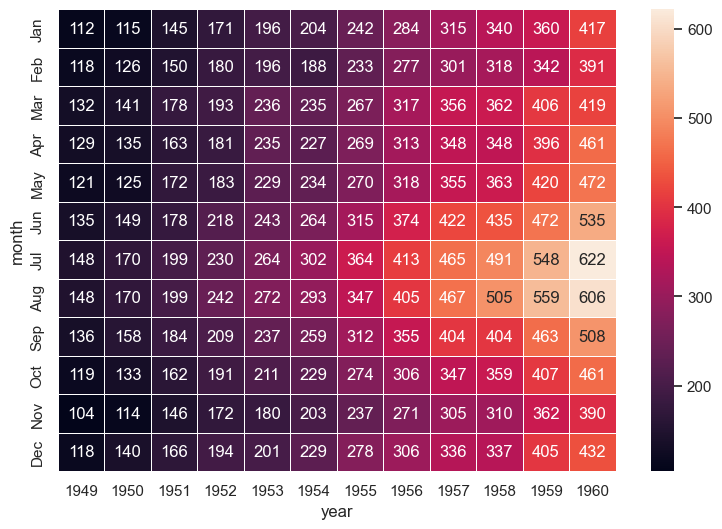

In [5]:
sns.set_theme()

f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(flights, annot=True, fmt="d", linewidths=.5, ax=ax)
plt.show()

Each cell is one month of one year, and a lighter cell has more passengers.
The numbers are in thousands: the cell of July 1960 says 622, which is 622,000 passengers.

The figure shows two patterns at once.
The numbers grow from left to right, so more people fly each year.
In every column the cells of July and August have the highest numbers, so most people fly in the summer.

## Interactive scatter plot with Plotly

[Plotly](https://plotly.com/python/) makes interactive figures for a web page.
The reader can move the mouse over a point to see its values, zoom into a part of the figure, and hide a group.

Plotly Express (`px`) is the short interface of Plotly: one call makes a figure from a table.
The example plots the iris data, which is four measurements of 150 flowers of three species.
`px.data.iris()` is the copy of the iris data inside Plotly. Two of its 150 rows differ from
the table of the pair plot notebook.

`hover_data` adds two more columns to the box that appears when the mouse is over a point.

In [6]:
iris = px.data.iris()
fig = px.scatter(
    iris, x="sepal_length", y="petal_length", color="species",
    hover_data=["sepal_width", "petal_width"],
)
fig.show()

The figure is a scatter plot with one color for each species.
Try three things:

- Move the mouse over a point. A box shows the species and the four measurements of that flower.
- Drag a rectangle to zoom in. A double click resets the view.
- Click a species in the legend to hide it. Click it again to show it.

## Save the interactive figure

`fig.write_html` saves the figure as a web page that keeps the interactions.
You can open the file in a browser, send it to someone, or embed it in a website.

In [7]:
os.makedirs("output", exist_ok=True)
fig.write_html("output/iris-scatter.html", include_plotlyjs="cdn")

The cell writes the file `output/iris-scatter.html`.

With `include_plotlyjs="cdn"`, the file is small, less than 20 KB, and it loads the Plotly library from the web when a reader opens it.
Without this argument, the file holds the whole library and has more than 4 MB.

A report needs a static image.
The camera button in the toolbar of the figure downloads the current view as a PNG file.